In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Raw data from your table:
# -------------------------
#              Pytorch                          fastLoader
#              Duration  CPU (I/O)  Mem (I/O)   GPU (I/O)   Duration  CPU (I/O)  Mem (I/O)   GPU (I/O)
# Node1:       231.33    2406.6584 323.0194    10641.39     128.08    979.5884  143.7044    25.14
# Node2:       231.70    1044.354  325.936     10408.30     132.06    516.2472  140.5248    115.48

# For plotting stacked bars, we focus on CPU and Memory (I/O) energies:
# Pytorch node1: CPU=2406.6584,  Mem=323.0194
# Pytorch node2: CPU=1044.354,   Mem=325.936
# Sum           : CPU=3451.0124, Mem=648.9554

pytorch_node1 = (2406.6584, 323.0194)
pytorch_node2 = (1044.354,  325.936)
pytorch_total = (pytorch_node1[0] + pytorch_node2[0],
                 pytorch_node1[1] + pytorch_node2[1])

# fastLoader node1: CPU=979.5884, Mem=143.7044
# fastLoader node2: CPU=516.2472, Mem=140.5248
# Sum             : CPU=1495.8356, Mem=284.2292

fastloader_node1 = (979.5884,  143.7044)
fastloader_node2 = (516.2472,  140.5248)
fastloader_total = (fastloader_node1[0] + fastloader_node2[0],
                    fastloader_node1[1] + fastloader_node2[1])

# We’ll also compute average durations for Pytorch vs fastLoader:
pytorch_duration_node1 = 231.33
pytorch_duration_node2 = 231.70
pytorch_avg_duration = (pytorch_duration_node1 + pytorch_duration_node2) / 2  # ~231.515

fastloader_duration_node1 = 128.08
fastloader_duration_node2 = 132.06
fastloader_avg_duration = (fastloader_duration_node1 + fastloader_duration_node2) / 2  # ~130.07

# ------------------------------
# Compute improvements in % form
# ------------------------------
def percent_improvement(old_val, new_val):
    """Return the percentage improvement going from old_val to new_val."""
    decrease = old_val - new_val
    return (decrease / old_val) * 100.0

# 1) Time
time_improvement = percent_improvement(pytorch_avg_duration, fastloader_avg_duration)

# 2) CPU
pytorch_total_cpu = pytorch_total[0]  # 3451.0124
fastloader_total_cpu = fastloader_total[0]  # 1495.8356
cpu_improvement = percent_improvement(pytorch_total_cpu, fastloader_total_cpu)

# 3) Memory
pytorch_total_mem = pytorch_total[1]  # 648.9554
fastloader_total_mem = fastloader_total[1]  # 284.2292
mem_improvement = percent_improvement(pytorch_total_mem, fastloader_total_mem)

# Print the results (you can adjust formatting)
print(f"--- Comparison of PyTorch vs fastLoader ---")
print(f"Average Time: Pytorch = {pytorch_avg_duration:.2f}s, fastLoader = {fastloader_avg_duration:.2f}s "
      f"({time_improvement:.1f}% improvement).")
print(f"Total CPU Energy: Pytorch = {pytorch_total_cpu:.2f}, fastLoader = {fastloader_total_cpu:.2f} "
      f"({cpu_improvement:.1f}% improvement).")
print(f"Total Memory Energy: Pytorch = {pytorch_total_mem:.2f}, fastLoader = {fastloader_total_mem:.2f} "
      f"({mem_improvement:.1f}% improvement).")


--- Comparison of PyTorch vs fastLoader ---
Average Time: Pytorch = 231.51s, fastLoader = 130.07s (43.8% improvement).
Total CPU Energy: Pytorch = 3451.01, fastLoader = 1495.84 (56.7% improvement).
Total Memory Energy: Pytorch = 648.96, fastLoader = 284.23 (56.2% improvement).


--- Comparison of PyTorch vs fastLoader ---
Average Time: Pytorch = 231.51s, fastLoader = 130.07s (43.8% improvement).
Total CPU Energy: Pytorch = 3451.01, fastLoader = 1495.84 (56.7% improvement).
Total Memory Energy: Pytorch = 648.96, fastLoader = 284.23 (56.2% improvement).


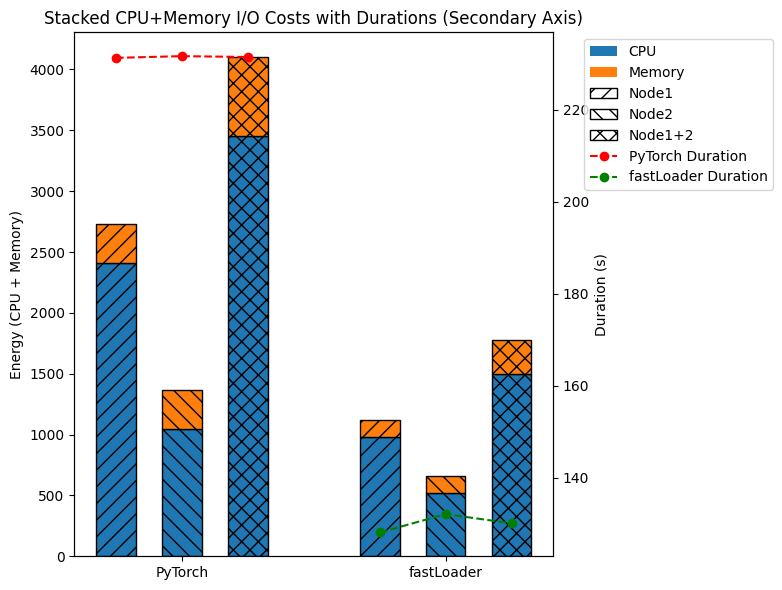

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# -------------------------
# 1) Raw Data from Your Table
# -------------------------
#                Pytorch                          fastLoader
#                Duration  CPU(I/O)   Mem(I/O)    GPU(I/O)     Duration  CPU(I/O)   Mem(I/O)   GPU(I/O)
# Node1:         231.33    2406.6584  323.0194    10641.39     128.08    979.5884   143.7044   25.14
# Node2:         231.70    1044.354   325.936     10408.30     132.06    516.2472   140.5248   115.48

# CPU + Memory energies (we'll stack these in the bars):
pytorch_node1 = (2406.6584, 323.0194)
pytorch_node2 = (1044.354,  325.936)
pytorch_comb  = (pytorch_node1[0] + pytorch_node2[0],
                 pytorch_node1[1] + pytorch_node2[1])

fast_node1 = (979.5884,  143.7044)
fast_node2 = (516.2472,  140.5248)
fast_comb  = (fast_node1[0] + fast_node2[0],
              fast_node1[1] + fast_node2[1])

# Durations
pytorch_dur_node1 = 231.33
pytorch_dur_node2 = 231.70
pytorch_dur_avg   = (pytorch_dur_node1 + pytorch_dur_node2) / 2  # ~231.515

fast_dur_node1 = 128.08
fast_dur_node2 = 132.06
fast_dur_avg   = (fast_dur_node1 + fast_dur_node2) / 2           # ~130.07

# Prepare lists for easy iteration
pytorch_bars = [pytorch_node1, pytorch_node2, pytorch_comb]
fast_bars    = [fast_node1,    fast_node2,    fast_comb]

pytorch_durs = [pytorch_dur_node1, pytorch_dur_node2, pytorch_dur_avg]
fast_durs    = [fast_dur_node1,    fast_dur_node2,    fast_dur_avg]

# ------------------------------
# 2) Compute improvements in % form
# ------------------------------
def percent_improvement(old_val, new_val):
    """Return the percentage improvement going from old_val to new_val."""
    return (old_val - new_val) / old_val * 100.0

pytorch_avg_duration = pytorch_dur_avg
fastloader_avg_duration = fast_dur_avg
time_improvement = percent_improvement(pytorch_avg_duration, fastloader_avg_duration)

pytorch_total_cpu = pytorch_comb[0]
fastloader_total_cpu = fast_comb[0]
cpu_improvement = percent_improvement(pytorch_total_cpu, fastloader_total_cpu)

pytorch_total_mem = pytorch_comb[1]
fastloader_total_mem = fast_comb[1]
mem_improvement = percent_improvement(pytorch_total_mem, fastloader_total_mem)

print(f"--- Comparison of PyTorch vs fastLoader ---")
print(f"Average Time: Pytorch = {pytorch_avg_duration:.2f}s, fastLoader = {fastloader_avg_duration:.2f}s "
      f"({time_improvement:.1f}% improvement).")
print(f"Total CPU Energy: Pytorch = {pytorch_total_cpu:.2f}, fastLoader = {fastloader_total_cpu:.2f} "
      f"({cpu_improvement:.1f}% improvement).")
print(f"Total Memory Energy: Pytorch = {pytorch_total_mem:.2f}, fastLoader = {fastloader_total_mem:.2f} "
      f"({mem_improvement:.1f}% improvement).")

# ------------------------------
# 3) Plotting
# ------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# We have two main x positions (0 -> PyTorch, 1 -> fastLoader)
x_main = np.array([0, 1], dtype=float)

# We'll create 3 sub‑bars at each x position with a small gap
bar_width = 0.15
offsets   = np.array([-0.25, 0.0, 0.25])  # Node1, Node2, Node1+2

# Colors for stacked bars
cpu_color = '#1f77b4'   # blue
mem_color = '#ff7f0e'   # orange

# Distinguish node1, node2, node1+2 via different hatch patterns
node_hatches = ['//', '\\\\', 'xx']  # adjust as you like

# --- Plot PyTorch stacked bars ---
for i, (cpu_val, mem_val) in enumerate(pytorch_bars):
    x_pos = x_main[0] + offsets[i]
    ax.bar(x_pos, cpu_val, bar_width,
           color=cpu_color, edgecolor='black', hatch=node_hatches[i])
    ax.bar(x_pos, mem_val, bar_width,
           bottom=cpu_val, color=mem_color, edgecolor='black', hatch=node_hatches[i])

# --- Plot fastLoader stacked bars ---
for i, (cpu_val, mem_val) in enumerate(fast_bars):
    x_pos = x_main[1] + offsets[i]
    ax.bar(x_pos, cpu_val, bar_width,
           color=cpu_color, edgecolor='black', hatch=node_hatches[i])
    ax.bar(x_pos, mem_val, bar_width,
           bottom=cpu_val, color=mem_color, edgecolor='black', hatch=node_hatches[i])

# Set x‑ticks to be in the middle of the group
ax.set_xticks(x_main)
ax.set_xticklabels(['PyTorch', 'fastLoader'])

ax.set_ylabel('Energy (CPU + Memory)')

# ------------------------------
# 4) Secondary Axis for Durations
# ------------------------------
ax2 = ax.twinx()

# Plot durations for PyTorch (single line with 3 points: Node1, Node2, Node1+2)
x_pytorch = x_main[0] + offsets
ax2.plot(x_pytorch, pytorch_durs, marker='o', linestyle='--', color='red', label='PyTorch Duration')

# Plot durations for fastLoader (single line with 3 points: Node1, Node2, Node1+2)
x_fast = x_main[1] + offsets
ax2.plot(x_fast, fast_durs, marker='o', linestyle='--', color='green', label='fastLoader Duration')

ax2.set_ylabel('Duration (s)')

# ------------------------------
# 5) Custom Legend & Layout
# ------------------------------
# We'll build a custom legend that shows:
#   - CPU color, Memory color
#   - Node1 hatch, Node2 hatch, Node1+2 hatch
#   - PyTorch line, fastLoader line

cpu_patch = mpatches.Patch(facecolor=cpu_color, label='CPU')
mem_patch = mpatches.Patch(facecolor=mem_color, label='Memory')

node1_patch = mpatches.Patch(facecolor='white', hatch='//', edgecolor='black', label='Node1')
node2_patch = mpatches.Patch(facecolor='white', hatch='\\\\', edgecolor='black', label='Node2')
node3_patch = mpatches.Patch(facecolor='white', hatch='xx', edgecolor='black', label='Node1+2')

py_line = mlines.Line2D([], [], color='red', marker='o', linestyle='--', label='PyTorch Duration')
fl_line = mlines.Line2D([], [], color='green', marker='o', linestyle='--', label='fastLoader Duration')

# Combine all handles in one legend
handles = [cpu_patch, mem_patch, node1_patch, node2_patch, node3_patch, py_line, fl_line]
ax2.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Stacked CPU+Memory I/O Costs with Durations (Secondary Axis)')
plt.tight_layout()
plt.show()


In [ ]:
## Total energy

--- Comparison of PyTorch vs fastLoader ---
Average Time: Pytorch = 231.51s, fastLoader = 130.07s (43.8% improvement).
Total CPU Energy: Pytorch = 43712.00, fastLoader = 24120.70 (44.8% improvement).
Total Memory Energy: Pytorch = 6955.35, fastLoader = 3826.54 (45.0% improvement).


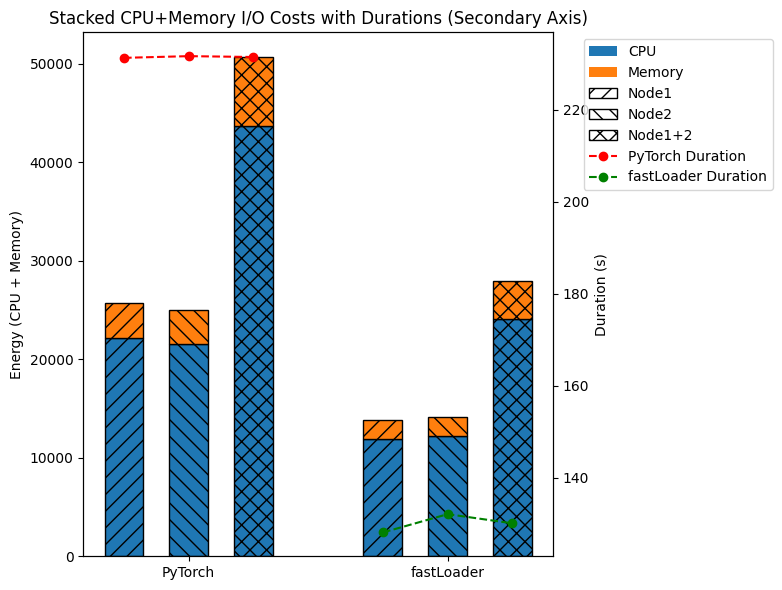

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# -------------------------
# 1) Raw Data from Your Table
# -------------------------
#                Pytorch                                        fastLoader
#                Duration  CPU(I/O)   Mem(I/O)    GPU(I/O)     Duration  CPU(I/O)   Mem(I/O)   GPU(I/O)
# Node1:         231.33	     22190	   3520	        14574	   128.08	  11932.99	1913.77	    2202.5
# Node2:         231.7	     21522	   3435.35	    13883.8	   132.06	  12187.71	1912.77	    2096.38

# CPU + Memory energies (we'll stack these in the bars):
pytorch_node1 = (22190, 3520)
pytorch_node2 = (21522,  3435.35)
pytorch_comb  = (pytorch_node1[0] + pytorch_node2[0],
                 pytorch_node1[1] + pytorch_node2[1])

fast_node1 = (11932.99,  1913.77)
fast_node2 = (12187.71,  1912.77)
fast_comb  = (fast_node1[0] + fast_node2[0],
              fast_node1[1] + fast_node2[1])

# Durations
pytorch_dur_node1 = 231.33
pytorch_dur_node2 = 231.70
pytorch_dur_avg   = (pytorch_dur_node1 + pytorch_dur_node2) / 2  # ~231.515

fast_dur_node1 = 128.08
fast_dur_node2 = 132.06
fast_dur_avg   = (fast_dur_node1 + fast_dur_node2) / 2           # ~130.07

# Prepare lists for easy iteration
pytorch_bars = [pytorch_node1, pytorch_node2, pytorch_comb]
fast_bars    = [fast_node1,    fast_node2,    fast_comb]

pytorch_durs = [pytorch_dur_node1, pytorch_dur_node2, pytorch_dur_avg]
fast_durs    = [fast_dur_node1,    fast_dur_node2,    fast_dur_avg]

# ------------------------------
# 2) Compute improvements in % form
# ------------------------------
def percent_improvement(old_val, new_val):
    """Return the percentage improvement going from old_val to new_val."""
    return (old_val - new_val) / old_val * 100.0

pytorch_avg_duration = pytorch_dur_avg
fastloader_avg_duration = fast_dur_avg
time_improvement = percent_improvement(pytorch_avg_duration, fastloader_avg_duration)

pytorch_total_cpu = pytorch_comb[0]
fastloader_total_cpu = fast_comb[0]
cpu_improvement = percent_improvement(pytorch_total_cpu, fastloader_total_cpu)

pytorch_total_mem = pytorch_comb[1]
fastloader_total_mem = fast_comb[1]
mem_improvement = percent_improvement(pytorch_total_mem, fastloader_total_mem)

print(f"--- Comparison of PyTorch vs fastLoader ---")
print(f"Average Time: Pytorch = {pytorch_avg_duration:.2f}s, fastLoader = {fastloader_avg_duration:.2f}s "
      f"({time_improvement:.1f}% improvement).")
print(f"Total CPU Energy: Pytorch = {pytorch_total_cpu:.2f}, fastLoader = {fastloader_total_cpu:.2f} "
      f"({cpu_improvement:.1f}% improvement).")
print(f"Total Memory Energy: Pytorch = {pytorch_total_mem:.2f}, fastLoader = {fastloader_total_mem:.2f} "
      f"({mem_improvement:.1f}% improvement).")

# ------------------------------
# 3) Plotting
# ------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# We have two main x positions (0 -> PyTorch, 1 -> fastLoader)
x_main = np.array([0, 1], dtype=float)

# We'll create 3 sub‑bars at each x position with a small gap
bar_width = 0.15
offsets   = np.array([-0.25, 0.0, 0.25])  # Node1, Node2, Node1+2

# Colors for stacked bars
cpu_color = '#1f77b4'   # blue
mem_color = '#ff7f0e'   # orange

# Distinguish node1, node2, node1+2 via different hatch patterns
node_hatches = ['//', '\\\\', 'xx']  # adjust as you like

# --- Plot PyTorch stacked bars ---
for i, (cpu_val, mem_val) in enumerate(pytorch_bars):
    x_pos = x_main[0] + offsets[i]
    ax.bar(x_pos, cpu_val, bar_width,
           color=cpu_color, edgecolor='black', hatch=node_hatches[i])
    ax.bar(x_pos, mem_val, bar_width,
           bottom=cpu_val, color=mem_color, edgecolor='black', hatch=node_hatches[i])

# --- Plot fastLoader stacked bars ---
for i, (cpu_val, mem_val) in enumerate(fast_bars):
    x_pos = x_main[1] + offsets[i]
    ax.bar(x_pos, cpu_val, bar_width,
           color=cpu_color, edgecolor='black', hatch=node_hatches[i])
    ax.bar(x_pos, mem_val, bar_width,
           bottom=cpu_val, color=mem_color, edgecolor='black', hatch=node_hatches[i])

# Set x‑ticks to be in the middle of the group
ax.set_xticks(x_main)
ax.set_xticklabels(['PyTorch', 'fastLoader'])

ax.set_ylabel('Energy (CPU + Memory)')

# ------------------------------
# 4) Secondary Axis for Durations
# ------------------------------
ax2 = ax.twinx()

# Plot durations for PyTorch (single line with 3 points: Node1, Node2, Node1+2)
x_pytorch = x_main[0] + offsets
ax2.plot(x_pytorch, pytorch_durs, marker='o', linestyle='--', color='red', label='PyTorch Duration')

# Plot durations for fastLoader (single line with 3 points: Node1, Node2, Node1+2)
x_fast = x_main[1] + offsets
ax2.plot(x_fast, fast_durs, marker='o', linestyle='--', color='green', label='fastLoader Duration')

ax2.set_ylabel('Duration (s)')

# ------------------------------
# 5) Custom Legend & Layout
# ------------------------------
# We'll build a custom legend that shows:
#   - CPU color, Memory color
#   - Node1 hatch, Node2 hatch, Node1+2 hatch
#   - PyTorch line, fastLoader line

cpu_patch = mpatches.Patch(facecolor=cpu_color, label='CPU')
mem_patch = mpatches.Patch(facecolor=mem_color, label='Memory')

node1_patch = mpatches.Patch(facecolor='white', hatch='//', edgecolor='black', label='Node1')
node2_patch = mpatches.Patch(facecolor='white', hatch='\\\\', edgecolor='black', label='Node2')
node3_patch = mpatches.Patch(facecolor='white', hatch='xx', edgecolor='black', label='Node1+2')

py_line = mlines.Line2D([], [], color='red', marker='o', linestyle='--', label='PyTorch Duration')
fl_line = mlines.Line2D([], [], color='green', marker='o', linestyle='--', label='fastLoader Duration')

# Combine all handles in one legend
handles = [cpu_patch, mem_patch, node1_patch, node2_patch, node3_patch, py_line, fl_line]
ax2.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Stacked CPU+Memory I/O Costs with Durations (Secondary Axis)')
plt.tight_layout()
plt.show()


In [1]:
##Training

----- PyTorch vs fastLoader Comparison (including GPU) -----
Avg Duration: Pytorch = 356.50s, fastLoader = 351.68s, improvement = 1.35%
CPU Energy: Pytorch = 5256.15, fastLoader = 5263.65, improvement = -0.14%
Memory Energy: Pytorch = 807.74, fastLoader = 890.54, improvement = -10.25%
GPU Energy: Pytorch = 96039.00, fastLoader = 95087.08, improvement = 0.99%
Total Energy: Pytorch = 102102.89, fastLoader = 101241.26, improvement = 0.84%


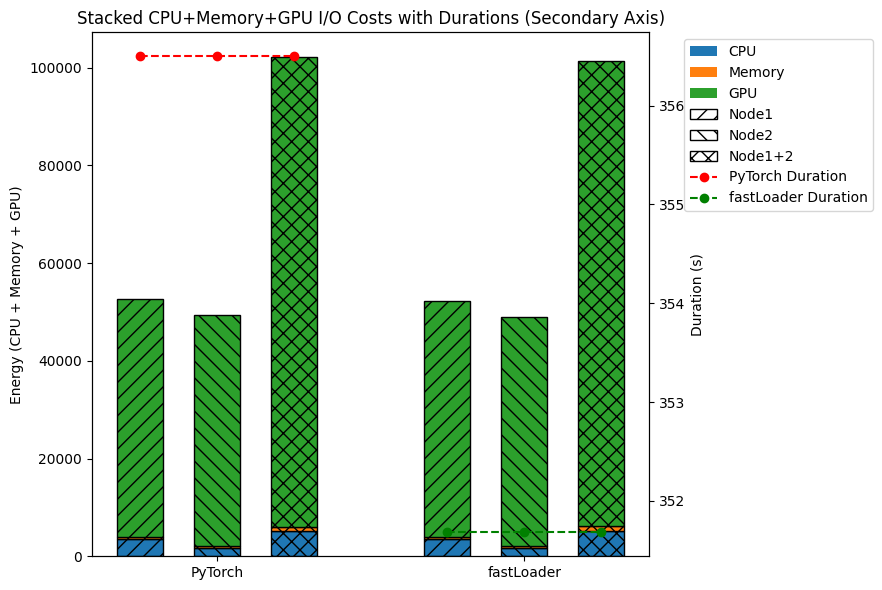

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# -------------------------
# 1) Raw Data (from your table)
# -------------------------
# For PyTorch (Node1, Node2):
#   CPU (I/O), Memory (I/O), GPU (I/O), Duration
pytorch_node1 = (3554.12, 410.87, 48667.6)
pytorch_node2 = (1702.03, 396.87, 47371.4)
pytorch_dur_node1 = 356.5
pytorch_dur_node2 = 356.5

# For fastLoader (Node1, Node2):
fast_node1 = (3548.8264, 450.4824, 48193.24)
fast_node2 = (1714.8216, 440.0544, 46893.84)
fast_dur_node1 = 351.68
fast_dur_node2 = 351.68

# -------------------------
# 2) Combine Node1 + Node2
# -------------------------
# We'll sum CPU, Mem, GPU for Node1+Node2
pytorch_comb = (pytorch_node1[0] + pytorch_node2[0],
                pytorch_node1[1] + pytorch_node2[1],
                pytorch_node1[2] + pytorch_node2[2])

fast_comb    = (fast_node1[0] + fast_node2[0],
                fast_node1[1] + fast_node2[1],
                fast_node1[2] + fast_node2[2])

# We’ll also define a “combined” duration as an average (you can choose sum if you prefer)
pytorch_dur_comb = (pytorch_dur_node1 + pytorch_dur_node2) / 2
fast_dur_comb    = (fast_dur_node1  + fast_dur_node2 ) / 2

# Prepare lists for easy iteration
pytorch_bars = [pytorch_node1, pytorch_node2, pytorch_comb]
fast_bars    = [fast_node1,    fast_node2,    fast_comb]

pytorch_durs = [pytorch_dur_node1, pytorch_dur_node2, pytorch_dur_comb]
fast_durs    = [fast_dur_node1,    fast_dur_node2,    fast_dur_comb]

# -------------------------
# 3) Compute Improvements
# -------------------------
def percent_improvement(old_val, new_val):
    """Return the percentage improvement going from old_val to new_val."""
    return (old_val - new_val) / old_val * 100.0

# CPU Improvement (PyTorch -> fastLoader)
cpu_old   = pytorch_comb[0]
cpu_new   = fast_comb[0]
cpu_impr  = percent_improvement(cpu_old, cpu_new)

# Memory Improvement
mem_old   = pytorch_comb[1]
mem_new   = fast_comb[1]
mem_impr  = percent_improvement(mem_old, mem_new)

# GPU Improvement
gpu_old   = pytorch_comb[2]
gpu_new   = fast_comb[2]
gpu_impr  = percent_improvement(gpu_old, gpu_new)

# Total Energy Improvement (CPU + Memory + GPU)
pytorch_total = cpu_old + mem_old + gpu_old
fast_total    = cpu_new + mem_new + gpu_new
total_impr    = percent_improvement(pytorch_total, fast_total)

# Duration Improvement
time_old  = pytorch_dur_comb
time_new  = fast_dur_comb
time_impr = percent_improvement(time_old, time_new)

print("----- PyTorch vs fastLoader Comparison (including GPU) -----")
print(f"Avg Duration: Pytorch = {time_old:.2f}s, fastLoader = {time_new:.2f}s, "
      f"improvement = {time_impr:.2f}%")
print(f"CPU Energy: Pytorch = {cpu_old:.2f}, fastLoader = {cpu_new:.2f}, improvement = {cpu_impr:.2f}%")
print(f"Memory Energy: Pytorch = {mem_old:.2f}, fastLoader = {mem_new:.2f}, improvement = {mem_impr:.2f}%")
print(f"GPU Energy: Pytorch = {gpu_old:.2f}, fastLoader = {gpu_new:.2f}, improvement = {gpu_impr:.2f}%")
print(f"Total Energy: Pytorch = {pytorch_total:.2f}, fastLoader = {fast_total:.2f}, "
      f"improvement = {total_impr:.2f}%")

# -------------------------
# 4) Plotting
# -------------------------
fig, ax = plt.subplots(figsize=(9, 6))

# We have two main x positions: 0 for PyTorch, 1 for fastLoader
x_main = np.array([0, 1], dtype=float)

# We'll create 3 sub-bars at each x position with a small gap
bar_width = 0.15
offsets   = np.array([-0.25, 0.0, 0.25])  # Node1, Node2, Node1+2

# Colors for the 3 layers in each bar
cpu_color = '#1f77b4'   # blue
mem_color = '#ff7f0e'   # orange
gpu_color = '#2ca02c'   # green

# Distinguish Node1, Node2, Node1+2 via different hatch patterns
node_hatches = ['//', '\\\\', 'xx']  # Node1, Node2, Node1+2

#
# Plot PyTorch bars (stack of CPU + Memory + GPU)
#
for i, (cpu_val, mem_val, gpu_val) in enumerate(pytorch_bars):
    x_pos = x_main[0] + offsets[i]

    # Bottom = CPU
    bottom_cpu = 0
    ax.bar(x_pos, cpu_val, bar_width,
           color=cpu_color, edgecolor='black',
           hatch=node_hatches[i])

    # Middle = Memory
    bottom_mem = cpu_val
    ax.bar(x_pos, mem_val, bar_width,
           bottom=bottom_mem,
           color=mem_color, edgecolor='black',
           hatch=node_hatches[i])

    # Top = GPU
    bottom_gpu = cpu_val + mem_val
    ax.bar(x_pos, gpu_val, bar_width,
           bottom=bottom_gpu,
           color=gpu_color, edgecolor='black',
           hatch=node_hatches[i])

#
# Plot fastLoader bars (stack of CPU + Memory + GPU)
#
for i, (cpu_val, mem_val, gpu_val) in enumerate(fast_bars):
    x_pos = x_main[1] + offsets[i]

    # Bottom = CPU
    bottom_cpu = 0
    ax.bar(x_pos, cpu_val, bar_width,
           color=cpu_color, edgecolor='black',
           hatch=node_hatches[i])

    # Middle = Memory
    bottom_mem = cpu_val
    ax.bar(x_pos, mem_val, bar_width,
           bottom=bottom_mem,
           color=mem_color, edgecolor='black',
           hatch=node_hatches[i])

    # Top = GPU
    bottom_gpu = cpu_val + mem_val
    ax.bar(x_pos, gpu_val, bar_width,
           bottom=bottom_gpu,
           color=gpu_color, edgecolor='black',
           hatch=node_hatches[i])

# Set x-ticks to be in the middle of the group
ax.set_xticks(x_main)
ax.set_xticklabels(['PyTorch', 'fastLoader'])

ax.set_ylabel('Energy (CPU + Memory + GPU)')

# ------------------------------
# 5) Secondary Axis for Durations
# ------------------------------
ax2 = ax.twinx()

# Plot durations for PyTorch
x_pytorch = x_main[0] + offsets
ax2.plot(x_pytorch, pytorch_durs, marker='o', linestyle='--', color='red', label='PyTorch Duration')

# Plot durations for fastLoader
x_fast = x_main[1] + offsets
ax2.plot(x_fast, fast_durs, marker='o', linestyle='--', color='green', label='fastLoader Duration')

ax2.set_ylabel('Duration (s)')

# ------------------------------
# 6) Custom Legend & Layout
# ------------------------------
# We'll build a custom legend that shows:
#   - CPU, Memory, GPU colors
#   - Node1, Node2, Node1+2 hatches
#   - PyTorch and fastLoader lines
cpu_patch = mpatches.Patch(facecolor=cpu_color, label='CPU')
mem_patch = mpatches.Patch(facecolor=mem_color, label='Memory')
gpu_patch = mpatches.Patch(facecolor=gpu_color, label='GPU')

node1_patch = mpatches.Patch(facecolor='white', hatch='//', edgecolor='black', label='Node1')
node2_patch = mpatches.Patch(facecolor='white', hatch='\\\\', edgecolor='black', label='Node2')
node3_patch = mpatches.Patcah(facecolor='white', hatch='xx', edgecolor='black', label='Node1+2')

py_line = mlines.Line2D([], [], color='red', marker='o', linestyle='--', label='PyTorch Duration')
fl_line = mlines.Line2D([], [], color='green', marker='o', linestyle='--', label='fastLoader Duration')

handles = [
    cpu_patch, mem_patch, gpu_patch,
    node1_patch, node2_patch, node3_patch,
    py_line, fl_line
]
ax2.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Stacked CPU+Memory+GPU I/O Costs with Durations (Secondary Axis)')
plt.tight_layout()

# If you're in an interactive environment (e.g., Jupyter), this will display the plot.
plt.show()

# If you're in a non-interactive environment (e.g., a Python script on a remote server),
# you might need to save the figure instead:
# plt.savefig("myplot.png")


In [2]:
## Total energy

----- PyTorch vs fastLoader Comparison (including GPU) -----
Avg Duration: Pytorch = 356.50s, fastLoader = 351.68s, improvement = 1.35%
CPU Energy: Pytorch = 67251.50, fastLoader = 66420.80, improvement = 1.24%
Memory Energy: Pytorch = 10518.80, fastLoader = 10470.30, improvement = 0.46%
GPU Energy: Pytorch = 107447.00, fastLoader = 106340.84, improvement = 1.03%
Total Energy: Pytorch = 185217.30, fastLoader = 183231.94, improvement = 1.07%


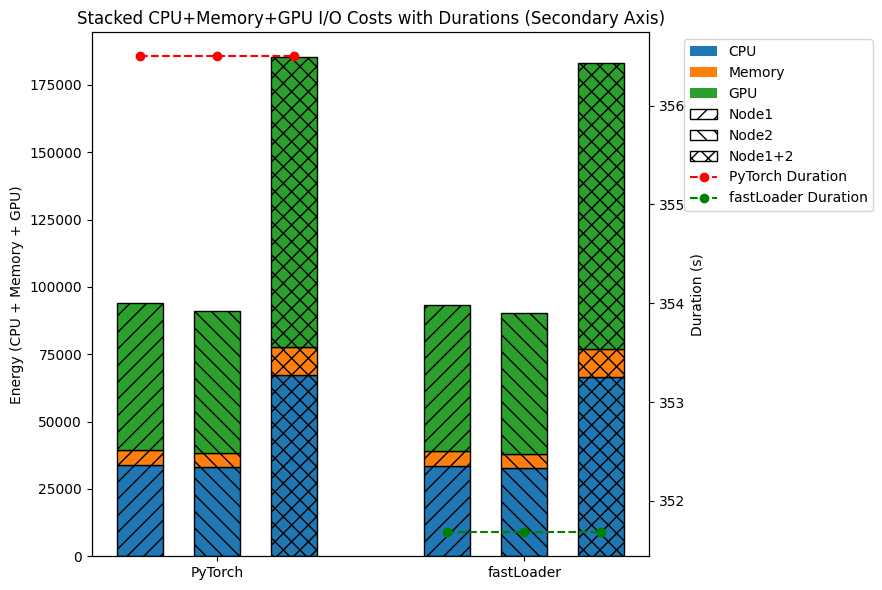

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


# 	Pytorch				fastLoader			
# 	Duration	CPU energy	Memory energy	GPU energy	Duration	CPU energy	Memory energy	GPU energy
# Node1	356.5	34042	5337.7	54728.1	351.68	33624.5	5310.7	54171.8
# Node2	356.5	33209.5	5181.1	52718.9	351.68	32796.3	5159.6	52169.04

# -------------------------
# 1) Raw Data (from your table)
# -------------------------
# For PyTorch (Node1, Node2):
#   CPU (I/O), Memory (I/O), GPU (I/O), Duration
pytorch_node1 = (34042,	5337.7,	54728.1)
pytorch_node2 = (33209.5,	5181.1,	52718.9)
pytorch_dur_node1 = 356.5
pytorch_dur_node2 = 356.5

# For fastLoader (Node1, Node2):
fast_node1 = (33624.5,	5310.7,	54171.8)
fast_node2 = (32796.3,	5159.6,	52169.04)
fast_dur_node1 = 351.68
fast_dur_node2 = 351.68

# -------------------------
# 2) Combine Node1 + Node2
# -------------------------
# We'll sum CPU, Mem, GPU for Node1+Node2
pytorch_comb = (pytorch_node1[0] + pytorch_node2[0],
                pytorch_node1[1] + pytorch_node2[1],
                pytorch_node1[2] + pytorch_node2[2])

fast_comb    = (fast_node1[0] + fast_node2[0],
                fast_node1[1] + fast_node2[1],
                fast_node1[2] + fast_node2[2])

# We’ll also define a “combined” duration as an average (you can choose sum if you prefer)
pytorch_dur_comb = (pytorch_dur_node1 + pytorch_dur_node2) / 2
fast_dur_comb    = (fast_dur_node1  + fast_dur_node2 ) / 2

# Prepare lists for easy iteration
pytorch_bars = [pytorch_node1, pytorch_node2, pytorch_comb]
fast_bars    = [fast_node1,    fast_node2,    fast_comb]

pytorch_durs = [pytorch_dur_node1, pytorch_dur_node2, pytorch_dur_comb]
fast_durs    = [fast_dur_node1,    fast_dur_node2,    fast_dur_comb]

# -------------------------
# 3) Compute Improvements
# -------------------------
def percent_improvement(old_val, new_val):
    """Return the percentage improvement going from old_val to new_val."""
    return (old_val - new_val) / old_val * 100.0

# CPU Improvement (PyTorch -> fastLoader)
cpu_old   = pytorch_comb[0]
cpu_new   = fast_comb[0]
cpu_impr  = percent_improvement(cpu_old, cpu_new)

# Memory Improvement
mem_old   = pytorch_comb[1]
mem_new   = fast_comb[1]
mem_impr  = percent_improvement(mem_old, mem_new)

# GPU Improvement
gpu_old   = pytorch_comb[2]
gpu_new   = fast_comb[2]
gpu_impr  = percent_improvement(gpu_old, gpu_new)

# Total Energy Improvement (CPU + Memory + GPU)
pytorch_total = cpu_old + mem_old + gpu_old
fast_total    = cpu_new + mem_new + gpu_new
total_impr    = percent_improvement(pytorch_total, fast_total)

# Duration Improvement
time_old  = pytorch_dur_comb
time_new  = fast_dur_comb
time_impr = percent_improvement(time_old, time_new)

print("----- PyTorch vs fastLoader Comparison (including GPU) -----")
print(f"Avg Duration: Pytorch = {time_old:.2f}s, fastLoader = {time_new:.2f}s, "
      f"improvement = {time_impr:.2f}%")
print(f"CPU Energy: Pytorch = {cpu_old:.2f}, fastLoader = {cpu_new:.2f}, improvement = {cpu_impr:.2f}%")
print(f"Memory Energy: Pytorch = {mem_old:.2f}, fastLoader = {mem_new:.2f}, improvement = {mem_impr:.2f}%")
print(f"GPU Energy: Pytorch = {gpu_old:.2f}, fastLoader = {gpu_new:.2f}, improvement = {gpu_impr:.2f}%")
print(f"Total Energy: Pytorch = {pytorch_total:.2f}, fastLoader = {fast_total:.2f}, "
      f"improvement = {total_impr:.2f}%")

# -------------------------
# 4) Plotting
# -------------------------
fig, ax = plt.subplots(figsize=(9, 6))

# We have two main x positions: 0 for PyTorch, 1 for fastLoader
x_main = np.array([0, 1], dtype=float)

# We'll create 3 sub-bars at each x position with a small gap
bar_width = 0.15
offsets   = np.array([-0.25, 0.0, 0.25])  # Node1, Node2, Node1+2

# Colors for the 3 layers in each bar
cpu_color = '#1f77b4'   # blue
mem_color = '#ff7f0e'   # orange
gpu_color = '#2ca02c'   # green

# Distinguish Node1, Node2, Node1+2 via different hatch patterns
node_hatches = ['//', '\\\\', 'xx']  # Node1, Node2, Node1+2

#
# Plot PyTorch bars (stack of CPU + Memory + GPU)
#
for i, (cpu_val, mem_val, gpu_val) in enumerate(pytorch_bars):
    x_pos = x_main[0] + offsets[i]

    # Bottom = CPU
    bottom_cpu = 0
    ax.bar(x_pos, cpu_val, bar_width,
           color=cpu_color, edgecolor='black',
           hatch=node_hatches[i])

    # Middle = Memory
    bottom_mem = cpu_val
    ax.bar(x_pos, mem_val, bar_width,
           bottom=bottom_mem,
           color=mem_color, edgecolor='black',
           hatch=node_hatches[i])

    # Top = GPU
    bottom_gpu = cpu_val + mem_val
    ax.bar(x_pos, gpu_val, bar_width,
           bottom=bottom_gpu,
           color=gpu_color, edgecolor='black',
           hatch=node_hatches[i])

#
# Plot fastLoader bars (stack of CPU + Memory + GPU)
#
for i, (cpu_val, mem_val, gpu_val) in enumerate(fast_bars):
    x_pos = x_main[1] + offsets[i]

    # Bottom = CPU
    bottom_cpu = 0
    ax.bar(x_pos, cpu_val, bar_width,
           color=cpu_color, edgecolor='black',
           hatch=node_hatches[i])

    # Middle = Memory
    bottom_mem = cpu_val
    ax.bar(x_pos, mem_val, bar_width,
           bottom=bottom_mem,
           color=mem_color, edgecolor='black',
           hatch=node_hatches[i])

    # Top = GPU
    bottom_gpu = cpu_val + mem_val
    ax.bar(x_pos, gpu_val, bar_width,
           bottom=bottom_gpu,
           color=gpu_color, edgecolor='black',
           hatch=node_hatches[i])

# Set x-ticks to be in the middle of the group
ax.set_xticks(x_main)
ax.set_xticklabels(['PyTorch', 'fastLoader'])

ax.set_ylabel('Energy (CPU + Memory + GPU)')

# ------------------------------
# 5) Secondary Axis for Durations
# ------------------------------
ax2 = ax.twinx()

# Plot durations for PyTorch
x_pytorch = x_main[0] + offsets
ax2.plot(x_pytorch, pytorch_durs, marker='o', linestyle='--', color='red', label='PyTorch Duration')

# Plot durations for fastLoader
x_fast = x_main[1] + offsets
ax2.plot(x_fast, fast_durs, marker='o', linestyle='--', color='green', label='fastLoader Duration')

ax2.set_ylabel('Duration (s)')

# ------------------------------
# 6) Custom Legend & Layout
# ------------------------------
# We'll build a custom legend that shows:
#   - CPU, Memory, GPU colors
#   - Node1, Node2, Node1+2 hatches
#   - PyTorch and fastLoader lines
cpu_patch = mpatches.Patch(facecolor=cpu_color, label='CPU')
mem_patch = mpatches.Patch(facecolor=mem_color, label='Memory')
gpu_patch = mpatches.Patch(facecolor=gpu_color, label='GPU')

node1_patch = mpatches.Patch(facecolor='white', hatch='//', edgecolor='black', label='Node1')
node2_patch = mpatches.Patch(facecolor='white', hatch='\\\\', edgecolor='black', label='Node2')
node3_patch = mpatches.Patch(facecolor='white', hatch='xx', edgecolor='black', label='Node1+2')

py_line = mlines.Line2D([], [], color='red', marker='o', linestyle='--', label='PyTorch Duration')
fl_line = mlines.Line2D([], [], color='green', marker='o', linestyle='--', label='fastLoader Duration')

handles = [
    cpu_patch, mem_patch, gpu_patch,
    node1_patch, node2_patch, node3_patch,
    py_line, fl_line
]
ax2.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Stacked CPU+Memory+GPU I/O Costs with Durations (Secondary Axis)')
plt.tight_layout()

# If you're in an interactive environment (e.g., Jupyter), this will display the plot.
plt.show()

# If you're in a non-interactive environment (e.g., a Python script on a remote server),
# you might need to save the figure instead:
# plt.savefig("myplot.png")


In [6]:
import re

def parse_accuracies(file_path):
    """
    Parse a text file and extract all accuracy values (both 'Acc:' and 'Accuracy:').
    Returns a list of floats (the numeric accuracy values).
    """
    # Regex captures either 'Acc' or 'Accuracy', followed by a colon,
    # some optional whitespace, then a floating number, and finally a '%' sign.
    pattern = re.compile(r'(?:Acc|Accuracy):\s+([\d.]+)%')
    
    accuracies = []
    with open(file_path, 'r') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                # Convert the matched string to float
                value = float(match.group(1))
                accuracies.append(value)
    
    return accuracies

# Example usage:
my_accuracies_fastLoader = parse_accuracies("/home/cc/fastLoader/fastLoader_training_results.txt")
print(my_accuracies_fastLoader, len (my_accuracies_fastLoader))
my_accuracies_fastloader_withoutpreprocessed= [0.62, 0.47, 0.31, 0.23, 0.19, 0.16, 0.13, 0.12, 0.1, 0.12, 0.11, 0.13, 0.14, 0.2, 0.19, 0.2, 0.31, 0.31, 0.62, 0.47, 0.38, 0.36, 0.36, 0.35, 0.42, 0.38, 0.37, 0.39, 0.41, 0.47, 0.47, 0.43, 0.31, 1.09, 0.83, 0.86, 0.94, 0.89, 0.98, 1.02, 1.04, 1.09, 1.08, 1.02, 1.01, 1.09, 1.1, 1.31, 2.5, 2.81, 2.29, 2.27, 2.25, 2.5, 2.37, 2.3, 2.6, 2.69, 2.73, 2.81, 2.79, 2.83, 2.91, 3.02, 2.81, 3.75, 4.38, 4.22, 4.31, 4.74, 4.73, 4.84, 4.9, 4.78, 5.2, 5.39, 5.65, 5.85, 6.47, 5.84, 2.1]

[0.31, 0.31, 0.21, 0.16, 0.12, 0.1, 0.09, 0.08, 0.07, 0.09, 0.09, 0.1, 0.14, 0.18, 0.17, 0.2, 0.31, 0.62, 0.83, 0.62, 0.5, 0.47, 0.45, 0.43, 0.49, 0.44, 0.43, 0.44, 0.46, 0.51, 0.52, 0.43, 0.31, 0.78, 0.73, 0.78, 0.69, 0.78, 0.89, 0.94, 0.97, 1.06, 1.05, 0.99, 0.99, 1.07, 1.08, 1.34, 1.88, 2.5, 2.29, 2.19, 2.19, 2.34, 2.28, 2.3, 2.53, 2.69, 2.73, 2.76, 2.72, 2.77, 2.78, 2.97, 2.81, 3.75, 4.38, 4.22, 4.31, 4.74, 4.73, 4.84, 4.86, 4.75, 5.17, 5.39, 5.62, 5.8, 5.78, 6.38, 2.07] 81


In [1]:
### preprocessed fastloader

In [7]:
my_accuracies_pytorch = parse_accuracies("/home/cc/fastLoader/pytorch_training_results.txt")
print(my_accuracies_pytorch, len(my_accuracies_pytorch))

[0.0, 0.0, 0.0, 0.08, 0.06, 0.05, 0.13, 0.12, 0.1, 0.12, 0.11, 0.16, 0.14, 0.13, 0.13, 0.13, 0.31, 0.16, 0.1, 0.16, 0.25, 0.36, 0.45, 0.55, 0.59, 0.59, 0.57, 0.52, 0.53, 0.56, 0.54, 0.58, 0.94, 0.47, 0.73, 0.62, 0.81, 0.83, 0.76, 0.86, 0.9, 0.91, 0.94, 0.94, 0.89, 1.05, 1.06, 1.34, 3.12, 2.81, 2.4, 2.34, 2.38, 2.34, 2.46, 2.46, 2.4, 2.5, 2.84, 2.97, 3.08, 3.08, 3.14, 3.78, 5.94, 5.16, 5.94, 5.62, 5.75, 5.83, 6.07, 5.94, 5.9, 6.16, 6.36, 6.3, 6.49, 6.52, 6.51, 6.83, 2.28] 81


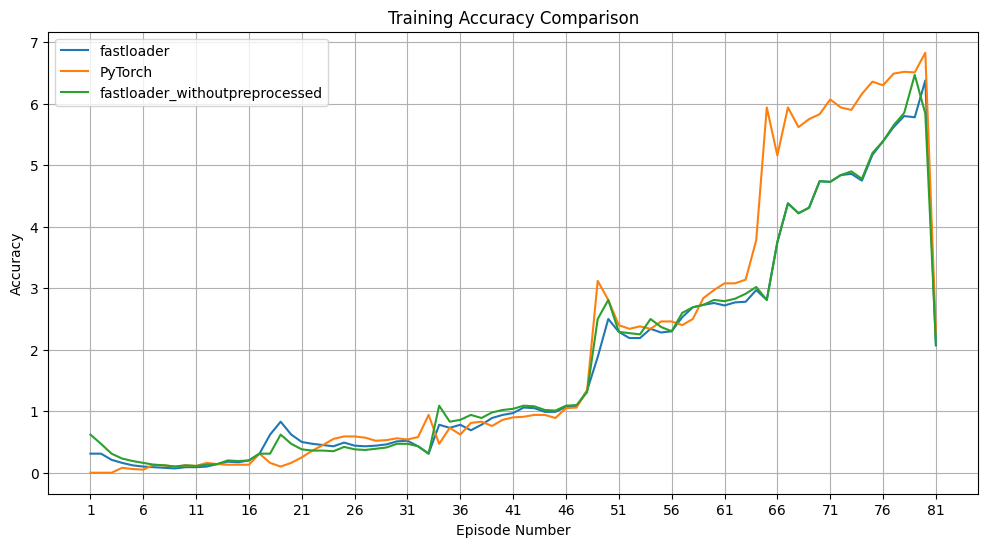

In [8]:
import matplotlib.pyplot as plt


episodes = list(range(1, len(my_accuracies_fastLoader) + 1))

plt.figure(figsize=(12, 6))
plt.plot(episodes, my_accuracies_fastLoader, label='fastloader')
plt.plot(episodes, my_accuracies_pytorch, label='PyTorch')
plt.plot(episodes, my_accuracies_fastloader_withoutpreprocessed, label='fastloader_withoutpreprocessed')

plt.xlabel('Episode Number')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Comparison')
plt.legend()
plt.grid(True)

# Adjust x-axis ticks to show every 5 episodes for clarity
plt.xticks(range(1, len(episodes) + 1, 5))

plt.show()

In [2]:
## fastloader with processor

In [3]:
# I/O only

----- PyTorch vs fastLoader Comparison (including GPU) -----
Avg Duration: Pytorch = 356.50s, fastLoader = 326.67s, improvement = 8.37%
CPU Energy: Pytorch = 5256.15, fastLoader = 5062.89, improvement = 3.68%
Memory Energy: Pytorch = 807.74, fastLoader = 885.21, improvement = -9.59%
GPU Energy: Pytorch = 96039.00, fastLoader = 94227.92, improvement = 1.89%
Total Energy: Pytorch = 102102.89, fastLoader = 100176.02, improvement = 1.89%


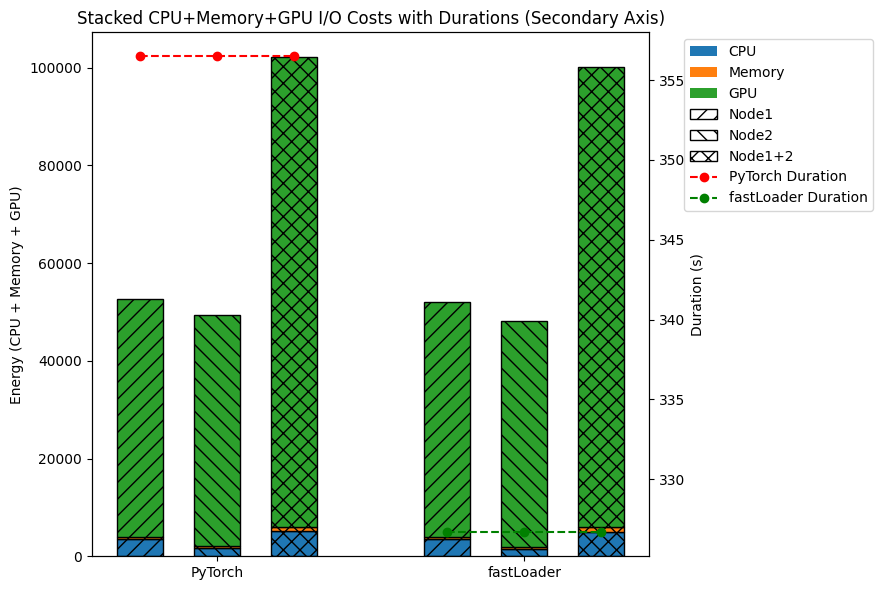

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


# 	Pytorch				fastLoader			
# 	Duration	I/O Cost CPU	I/O Cost Memory	I/O Cost GPU	Duration	I/O Cost CPU	I/O Cost Memory	I/O Cost GPU
# Node1	356.5	3554.12	410.87	48667.6	326.67	3544.6816	453.5206	47967.11
# Node2	356.5	1702.03	396.87	47371.4	326.67	1518.2054	431.6886	46260.81

# -------------------------
# 1) Raw Data (from your table)
# -------------------------
# For PyTorch (Node1, Node2):
#   CPU (I/O), Memory (I/O), GPU (I/O), Duration
pytorch_node1 = (3554.12,	410.87,	48667.6)
pytorch_node2 = (1702.03,	396.87,	47371.4)
pytorch_dur_node1 = 356.5
pytorch_dur_node2 = 356.5

# For fastLoader (Node1, Node2):
fast_node1 = (3544.6816,	453.5206,	47967.11)
fast_node2 = (1518.2054,	431.6886,	46260.81)
fast_dur_node1 = 326.67
fast_dur_node2 = 326.67

# -------------------------
# 2) Combine Node1 + Node2
# -------------------------
# We'll sum CPU, Mem, GPU for Node1+Node2
pytorch_comb = (pytorch_node1[0] + pytorch_node2[0],
                pytorch_node1[1] + pytorch_node2[1],
                pytorch_node1[2] + pytorch_node2[2])

fast_comb    = (fast_node1[0] + fast_node2[0],
                fast_node1[1] + fast_node2[1],
                fast_node1[2] + fast_node2[2])

# We’ll also define a “combined” duration as an average (you can choose sum if you prefer)
pytorch_dur_comb = (pytorch_dur_node1 + pytorch_dur_node2) / 2
fast_dur_comb    = (fast_dur_node1  + fast_dur_node2 ) / 2

# Prepare lists for easy iteration
pytorch_bars = [pytorch_node1, pytorch_node2, pytorch_comb]
fast_bars    = [fast_node1,    fast_node2,    fast_comb]

pytorch_durs = [pytorch_dur_node1, pytorch_dur_node2, pytorch_dur_comb]
fast_durs    = [fast_dur_node1,    fast_dur_node2,    fast_dur_comb]

# -------------------------
# 3) Compute Improvements
# -------------------------
def percent_improvement(old_val, new_val):
    """Return the percentage improvement going from old_val to new_val."""
    return (old_val - new_val) / old_val * 100.0

# CPU Improvement (PyTorch -> fastLoader)
cpu_old   = pytorch_comb[0]
cpu_new   = fast_comb[0]
cpu_impr  = percent_improvement(cpu_old, cpu_new)

# Memory Improvement
mem_old   = pytorch_comb[1]
mem_new   = fast_comb[1]
mem_impr  = percent_improvement(mem_old, mem_new)

# GPU Improvement
gpu_old   = pytorch_comb[2]
gpu_new   = fast_comb[2]
gpu_impr  = percent_improvement(gpu_old, gpu_new)

# Total Energy Improvement (CPU + Memory + GPU)
pytorch_total = cpu_old + mem_old + gpu_old
fast_total    = cpu_new + mem_new + gpu_new
total_impr    = percent_improvement(pytorch_total, fast_total)

# Duration Improvement
time_old  = pytorch_dur_comb
time_new  = fast_dur_comb
time_impr = percent_improvement(time_old, time_new)

print("----- PyTorch vs fastLoader Comparison (including GPU) -----")
print(f"Avg Duration: Pytorch = {time_old:.2f}s, fastLoader = {time_new:.2f}s, "
      f"improvement = {time_impr:.2f}%")
print(f"CPU Energy: Pytorch = {cpu_old:.2f}, fastLoader = {cpu_new:.2f}, improvement = {cpu_impr:.2f}%")
print(f"Memory Energy: Pytorch = {mem_old:.2f}, fastLoader = {mem_new:.2f}, improvement = {mem_impr:.2f}%")
print(f"GPU Energy: Pytorch = {gpu_old:.2f}, fastLoader = {gpu_new:.2f}, improvement = {gpu_impr:.2f}%")
print(f"Total Energy: Pytorch = {pytorch_total:.2f}, fastLoader = {fast_total:.2f}, "
      f"improvement = {total_impr:.2f}%")

# -------------------------
# 4) Plotting
# -------------------------
fig, ax = plt.subplots(figsize=(9, 6))

# We have two main x positions: 0 for PyTorch, 1 for fastLoader
x_main = np.array([0, 1], dtype=float)

# We'll create 3 sub-bars at each x position with a small gap
bar_width = 0.15
offsets   = np.array([-0.25, 0.0, 0.25])  # Node1, Node2, Node1+2

# Colors for the 3 layers in each bar
cpu_color = '#1f77b4'   # blue
mem_color = '#ff7f0e'   # orange
gpu_color = '#2ca02c'   # green

# Distinguish Node1, Node2, Node1+2 via different hatch patterns
node_hatches = ['//', '\\\\', 'xx']  # Node1, Node2, Node1+2

#
# Plot PyTorch bars (stack of CPU + Memory + GPU)
#
for i, (cpu_val, mem_val, gpu_val) in enumerate(pytorch_bars):
    x_pos = x_main[0] + offsets[i]

    # Bottom = CPU
    bottom_cpu = 0
    ax.bar(x_pos, cpu_val, bar_width,
           color=cpu_color, edgecolor='black',
           hatch=node_hatches[i])

    # Middle = Memory
    bottom_mem = cpu_val
    ax.bar(x_pos, mem_val, bar_width,
           bottom=bottom_mem,
           color=mem_color, edgecolor='black',
           hatch=node_hatches[i])

    # Top = GPU
    bottom_gpu = cpu_val + mem_val
    ax.bar(x_pos, gpu_val, bar_width,
           bottom=bottom_gpu,
           color=gpu_color, edgecolor='black',
           hatch=node_hatches[i])

#
# Plot fastLoader bars (stack of CPU + Memory + GPU)
#
for i, (cpu_val, mem_val, gpu_val) in enumerate(fast_bars):
    x_pos = x_main[1] + offsets[i]

    # Bottom = CPU
    bottom_cpu = 0
    ax.bar(x_pos, cpu_val, bar_width,
           color=cpu_color, edgecolor='black',
           hatch=node_hatches[i])

    # Middle = Memory
    bottom_mem = cpu_val
    ax.bar(x_pos, mem_val, bar_width,
           bottom=bottom_mem,
           color=mem_color, edgecolor='black',
           hatch=node_hatches[i])

    # Top = GPU
    bottom_gpu = cpu_val + mem_val
    ax.bar(x_pos, gpu_val, bar_width,
           bottom=bottom_gpu,
           color=gpu_color, edgecolor='black',
           hatch=node_hatches[i])

# Set x-ticks to be in the middle of the group
ax.set_xticks(x_main)
ax.set_xticklabels(['PyTorch', 'fastLoader'])

ax.set_ylabel('Energy (CPU + Memory + GPU)')

# ------------------------------
# 5) Secondary Axis for Durations
# ------------------------------
ax2 = ax.twinx()

# Plot durations for PyTorch
x_pytorch = x_main[0] + offsets
ax2.plot(x_pytorch, pytorch_durs, marker='o', linestyle='--', color='red', label='PyTorch Duration')

# Plot durations for fastLoader
x_fast = x_main[1] + offsets
ax2.plot(x_fast, fast_durs, marker='o', linestyle='--', color='green', label='fastLoader Duration')

ax2.set_ylabel('Duration (s)')

# ------------------------------
# 6) Custom Legend & Layout
# ------------------------------
# We'll build a custom legend that shows:
#   - CPU, Memory, GPU colors
#   - Node1, Node2, Node1+2 hatches
#   - PyTorch and fastLoader lines
cpu_patch = mpatches.Patch(facecolor=cpu_color, label='CPU')
mem_patch = mpatches.Patch(facecolor=mem_color, label='Memory')
gpu_patch = mpatches.Patch(facecolor=gpu_color, label='GPU')

node1_patch = mpatches.Patch(facecolor='white', hatch='//', edgecolor='black', label='Node1')
node2_patch = mpatches.Patch(facecolor='white', hatch='\\\\', edgecolor='black', label='Node2')
node3_patch = mpatches.Patch(facecolor='white', hatch='xx', edgecolor='black', label='Node1+2')

py_line = mlines.Line2D([], [], color='red', marker='o', linestyle='--', label='PyTorch Duration')
fl_line = mlines.Line2D([], [], color='green', marker='o', linestyle='--', label='fastLoader Duration')

handles = [
    cpu_patch, mem_patch, gpu_patch,
    node1_patch, node2_patch, node3_patch,
    py_line, fl_line
]
ax2.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Stacked CPU+Memory+GPU I/O Costs with Durations (Secondary Axis)')
plt.tight_layout()

# If you're in an interactive environment (e.g., Jupyter), this will display the plot.
plt.show()

# If you're in a non-interactive environment (e.g., a Python script on a remote server),
# you might need to save the figure instead:
# plt.savefig("myplot.png")


----- PyTorch vs fastLoader Comparison (including GPU) -----
Avg Duration: Pytorch = 356.50s, fastLoader = 326.67s, improvement = 8.37%
CPU Energy: Pytorch = 67251.50, fastLoader = 61870.80, improvement = 8.00%
Memory Energy: Pytorch = 10518.80, fastLoader = 9783.70, improvement = 6.99%
GPU Energy: Pytorch = 107447.00, fastLoader = 104681.36, improvement = 2.57%
Total Energy: Pytorch = 185217.30, fastLoader = 176335.86, improvement = 4.80%


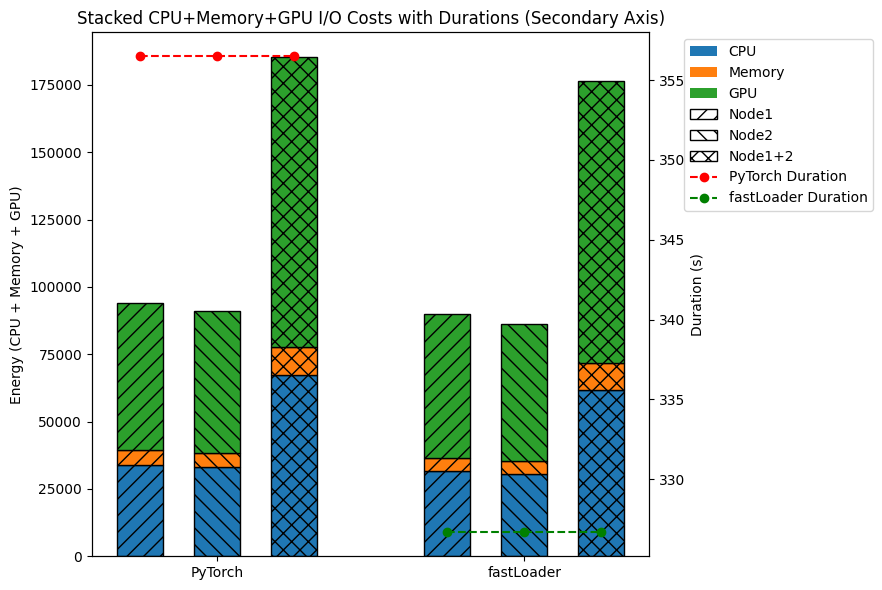

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


# 	Pytorch				fastLoader			
# 	Duration	CPU energy	Memory energy	GPU energy	Duration	CPU energy	Memory energy	GPU energy
# Node1		356.5 34042	5337.7	54728.1	326.67	31481.5	4968.1	53520.5
# Node2		356.5 33209.5	5181.1	52718.9	326.67	30389.3	4815.6	51160.86

# -------------------------
# 1) Raw Data (from your table)
# -------------------------
# For PyTorch (Node1, Node2):
#   CPU (I/O), Memory (I/O), GPU (I/O), Duration
pytorch_node1 = (34042,	5337.7,	54728.1)
pytorch_node2 = (33209.5,	5181.1,	52718.9)
pytorch_dur_node1 = 356.5
pytorch_dur_node2 = 356.5

# For fastLoader (Node1, Node2):
fast_node1 = (31481.5,	4968.1,	53520.5)
fast_node2 = (30389.3,	4815.6,	51160.86)
fast_dur_node1 = 326.67
fast_dur_node2 = 326.67

# -------------------------
# 2) Combine Node1 + Node2
# -------------------------
# We'll sum CPU, Mem, GPU for Node1+Node2
pytorch_comb = (pytorch_node1[0] + pytorch_node2[0],
                pytorch_node1[1] + pytorch_node2[1],
                pytorch_node1[2] + pytorch_node2[2])

fast_comb    = (fast_node1[0] + fast_node2[0],
                fast_node1[1] + fast_node2[1],
                fast_node1[2] + fast_node2[2])

# We’ll also define a “combined” duration as an average (you can choose sum if you prefer)
pytorch_dur_comb = (pytorch_dur_node1 + pytorch_dur_node2) / 2
fast_dur_comb    = (fast_dur_node1  + fast_dur_node2 ) / 2

# Prepare lists for easy iteration
pytorch_bars = [pytorch_node1, pytorch_node2, pytorch_comb]
fast_bars    = [fast_node1,    fast_node2,    fast_comb]

pytorch_durs = [pytorch_dur_node1, pytorch_dur_node2, pytorch_dur_comb]
fast_durs    = [fast_dur_node1,    fast_dur_node2,    fast_dur_comb]

# -------------------------
# 3) Compute Improvements
# -------------------------
def percent_improvement(old_val, new_val):
    """Return the percentage improvement going from old_val to new_val."""
    return (old_val - new_val) / old_val * 100.0

# CPU Improvement (PyTorch -> fastLoader)
cpu_old   = pytorch_comb[0]
cpu_new   = fast_comb[0]
cpu_impr  = percent_improvement(cpu_old, cpu_new)

# Memory Improvement
mem_old   = pytorch_comb[1]
mem_new   = fast_comb[1]
mem_impr  = percent_improvement(mem_old, mem_new)

# GPU Improvement
gpu_old   = pytorch_comb[2]
gpu_new   = fast_comb[2]
gpu_impr  = percent_improvement(gpu_old, gpu_new)

# Total Energy Improvement (CPU + Memory + GPU)
pytorch_total = cpu_old + mem_old + gpu_old
fast_total    = cpu_new + mem_new + gpu_new
total_impr    = percent_improvement(pytorch_total, fast_total)

# Duration Improvement
time_old  = pytorch_dur_comb
time_new  = fast_dur_comb
time_impr = percent_improvement(time_old, time_new)

print("----- PyTorch vs fastLoader Comparison (including GPU) -----")
print(f"Avg Duration: Pytorch = {time_old:.2f}s, fastLoader = {time_new:.2f}s, "
      f"improvement = {time_impr:.2f}%")
print(f"CPU Energy: Pytorch = {cpu_old:.2f}, fastLoader = {cpu_new:.2f}, improvement = {cpu_impr:.2f}%")
print(f"Memory Energy: Pytorch = {mem_old:.2f}, fastLoader = {mem_new:.2f}, improvement = {mem_impr:.2f}%")
print(f"GPU Energy: Pytorch = {gpu_old:.2f}, fastLoader = {gpu_new:.2f}, improvement = {gpu_impr:.2f}%")
print(f"Total Energy: Pytorch = {pytorch_total:.2f}, fastLoader = {fast_total:.2f}, "
      f"improvement = {total_impr:.2f}%")

# -------------------------
# 4) Plotting
# -------------------------
fig, ax = plt.subplots(figsize=(9, 6))

# We have two main x positions: 0 for PyTorch, 1 for fastLoader
x_main = np.array([0, 1], dtype=float)

# We'll create 3 sub-bars at each x position with a small gap
bar_width = 0.15
offsets   = np.array([-0.25, 0.0, 0.25])  # Node1, Node2, Node1+2

# Colors for the 3 layers in each bar
cpu_color = '#1f77b4'   # blue
mem_color = '#ff7f0e'   # orange
gpu_color = '#2ca02c'   # green

# Distinguish Node1, Node2, Node1+2 via different hatch patterns
node_hatches = ['//', '\\\\', 'xx']  # Node1, Node2, Node1+2

#
# Plot PyTorch bars (stack of CPU + Memory + GPU)
#
for i, (cpu_val, mem_val, gpu_val) in enumerate(pytorch_bars):
    x_pos = x_main[0] + offsets[i]

    # Bottom = CPU
    bottom_cpu = 0
    ax.bar(x_pos, cpu_val, bar_width,
           color=cpu_color, edgecolor='black',
           hatch=node_hatches[i])

    # Middle = Memory
    bottom_mem = cpu_val
    ax.bar(x_pos, mem_val, bar_width,
           bottom=bottom_mem,
           color=mem_color, edgecolor='black',
           hatch=node_hatches[i])

    # Top = GPU
    bottom_gpu = cpu_val + mem_val
    ax.bar(x_pos, gpu_val, bar_width,
           bottom=bottom_gpu,
           color=gpu_color, edgecolor='black',
           hatch=node_hatches[i])

#
# Plot fastLoader bars (stack of CPU + Memory + GPU)
#
for i, (cpu_val, mem_val, gpu_val) in enumerate(fast_bars):
    x_pos = x_main[1] + offsets[i]

    # Bottom = CPU
    bottom_cpu = 0
    ax.bar(x_pos, cpu_val, bar_width,
           color=cpu_color, edgecolor='black',
           hatch=node_hatches[i])

    # Middle = Memory
    bottom_mem = cpu_val
    ax.bar(x_pos, mem_val, bar_width,
           bottom=bottom_mem,
           color=mem_color, edgecolor='black',
           hatch=node_hatches[i])

    # Top = GPU
    bottom_gpu = cpu_val + mem_val
    ax.bar(x_pos, gpu_val, bar_width,
           bottom=bottom_gpu,
           color=gpu_color, edgecolor='black',
           hatch=node_hatches[i])

# Set x-ticks to be in the middle of the group
ax.set_xticks(x_main)
ax.set_xticklabels(['PyTorch', 'fastLoader'])

ax.set_ylabel('Energy (CPU + Memory + GPU)')

# ------------------------------
# 5) Secondary Axis for Durations
# ------------------------------
ax2 = ax.twinx()

# Plot durations for PyTorch
x_pytorch = x_main[0] + offsets
ax2.plot(x_pytorch, pytorch_durs, marker='o', linestyle='--', color='red', label='PyTorch Duration')

# Plot durations for fastLoader
x_fast = x_main[1] + offsets
ax2.plot(x_fast, fast_durs, marker='o', linestyle='--', color='green', label='fastLoader Duration')

ax2.set_ylabel('Duration (s)')

# ------------------------------
# 6) Custom Legend & Layout
# ------------------------------
# We'll build a custom legend that shows:
#   - CPU, Memory, GPU colors
#   - Node1, Node2, Node1+2 hatches
#   - PyTorch and fastLoader lines
cpu_patch = mpatches.Patch(facecolor=cpu_color, label='CPU')
mem_patch = mpatches.Patch(facecolor=mem_color, label='Memory')
gpu_patch = mpatches.Patch(facecolor=gpu_color, label='GPU')

node1_patch = mpatches.Patch(facecolor='white', hatch='//', edgecolor='black', label='Node1')
node2_patch = mpatches.Patch(facecolor='white', hatch='\\\\', edgecolor='black', label='Node2')
node3_patch = mpatches.Patch(facecolor='white', hatch='xx', edgecolor='black', label='Node1+2')

py_line = mlines.Line2D([], [], color='red', marker='o', linestyle='--', label='PyTorch Duration')
fl_line = mlines.Line2D([], [], color='green', marker='o', linestyle='--', label='fastLoader Duration')

handles = [
    cpu_patch, mem_patch, gpu_patch,
    node1_patch, node2_patch, node3_patch,
    py_line, fl_line
]
ax2.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Stacked CPU+Memory+GPU I/O Costs with Durations (Secondary Axis)')
plt.tight_layout()

# If you're in an interactive environment (e.g., Jupyter), this will display the plot.
plt.show()

# If you're in a non-interactive environment (e.g., a Python script on a remote server),
# you might need to save the figure instead:
# plt.savefig("myplot.png")
